# Data Pre-Processing -- Groups of Categories from TripAdvisor Data

In [1]:
import pandas as pd
import json
import geopandas as gpd

Note, this notebook is based on data resulting from the notebook called 'Analysis and Visualization -- KDE Plot and DBSCAN on Tripadvisor Data' and will only work if run after that file has been produced.

## reading in relevant data

In [2]:
# read in tripadvisor data and split categories

tripadvisor_attractions_df = gpd.read_file('tripadvisor_attractions_geo_cleaned.geojson')
tripadvisor_attractions_df['category'] = tripadvisor_attractions_df['category'].str.split('•').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)

In [3]:
tripadvisor_attractions_df.head(1)

,name,link,rating,review_count,category,address,latitude,longitude,X_metres,Y_metres,lbls,geometry
0,Hallgrimskirkja,https://www.tripadvisor.com/Attraction_Review-...,4.4,23266,[Churches & Cathedrals],"Hallgrimstorgi 1, Reykjavik 101 Iceland",64.14197,-21.92697,357552.558789,407644.449904,0,POINT (-21.92697 64.14197)


<Axes: >

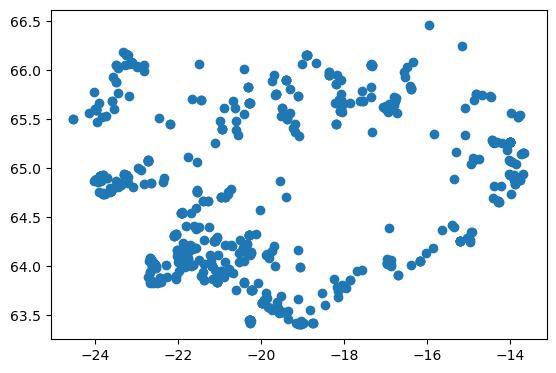

In [4]:
tripadvisor_attractions_df.plot()

## get unique categories

In [5]:
unique_categories = tripadvisor_attractions_df['category'].explode().unique()

# convert to list for easier handling
unique_list = sorted(unique_categories.tolist())

In [6]:
len(unique_list)

105

In [7]:
# unique_list

In [8]:
category_counts = tripadvisor_attractions_df['category'].explode().value_counts()

In [9]:
# category_counts[category_counts == 1]

In [10]:
# manually explored the categories to make sense of how to group them

Based on manually exploring the categories and the logic I intend to use in my routing, I have decided to create five groups of categories.

## assign group to each category

In [11]:
category_groups = {
    'Airport Lounges': 'Services',
    'Amusement & Theme Parks': 'Leisure',
    'Ancient Ruins': 'Culture',
    'Antique Shops': 'Leisure',
    'Aquariums': 'Nature/Adventure',
    'Architectural Buildings': 'Sightseeing',
    'Art Galleries': 'Culture',
    'Art Museums': 'Culture',
    'Balloon Rides': 'Nature/Adventure',
    'Bars & Clubs': 'Leisure',
    'Battlefields': 'Culture',
    'Beach & Pool Clubs': 'Leisure',
    'Beaches': 'Nature/Adventure',
    'Bodies of Water': 'Nature/Adventure',
    'Bowling Alleys': 'Leisure',
    'Breweries': 'Leisure',
    'Bridges': 'Sightseeing',
    'Canyons': 'Nature/Adventure',
    'Caverns & Caves': 'Nature/Adventure',
    'Cemeteries': 'Culture',
    "Children's Museums": 'Culture',
    'Churches & Cathedrals': 'Sightseeing',
    'Civic Centres': 'Sightseeing',
    'Coffeehouses': 'Leisure',
    'Comedy Clubs': 'Leisure',
    'Concerts': 'Culture',
    'Convention Centers': 'Services',
    'Cross-country Ski Areas': 'Nature/Adventure',
    'Dams': 'Sightseeing',
    'Dance Clubs & Discos': 'Leisure',
    'Deserts': 'Nature/Adventure',
    'Distilleries': 'Leisure',
    'Escape Games': 'Leisure',
    'Exhibitions': 'Culture',
    'Farmers Markets': 'Leisure',
    'Farms': 'Services',
    'Ferries': 'Services',
    'Flea & Street Markets': 'Leisure',
    'Food & Drink Festivals': 'Leisure',
    'Forests': 'Nature/Adventure',
    'Game & Entertainment Centers': 'Leisure',
    'Gardens': 'Nature/Adventure',
    'Gay Bars': 'Leisure',
    'Geologic Formations': 'Nature/Adventure',
    'Golf Courses': 'Leisure',
    'Government Buildings': 'Sightseeing',
    'Health Clubs': 'Leisure',
    'Hiking Trails': 'Nature/Adventure',
    'Historic Sites': 'Culture',
    'Historic Walking Areas': 'Culture',
    'History Museums': 'Culture',
    'Horse Tracks': 'Leisure',
    'Hot Springs & Geysers': 'Nature/Adventure',
    'Islands': 'Nature/Adventure',
    'Karaoke Bars': 'Leisure',
    'Kayaking & Canoeing': 'Nature/Adventure',
    'Lessons & Workshops': 'Services',
    'Libraries': 'Culture',
    'Lighthouses': 'Sightseeing',
    'Lookouts': 'Sightseeing',
    'Marinas': 'Services',
    'Military Museums': 'Culture',
    'Monuments & Statues': 'Sightseeing',
    'Mountains': 'Nature/Adventure',
    'Movie Theaters': 'Leisure',
    'National Parks': 'Nature/Adventure',
    'Natural History Museums': 'Culture',
    'Nature & Wildlife Areas': 'Nature/Adventure',
    'Observation Decks & Towers': 'Sightseeing',
    'Operas': 'Culture',
    'Paint & Pottery Studios': 'Leisure',
    'Parks': 'Nature/Adventure',
    'Piano Bars': 'Leisure',
    'Piers & Boardwalks': 'Sightseeing',
    'Playgrounds': 'Leisure',
    'Points of Interest & Landmarks': 'Sightseeing',
    'Public Transportation Systems': 'Services',
    'Religious Sites': 'Culture',
    'River Rafting & Tubing': 'Nature/Adventure',
    'Scenic Drives': 'Sightseeing',
    'Scenic Walking Areas': 'Nature/Adventure',
    'Scuba & Snorkelling': 'Nature/Adventure',
    'Ships': 'Sightseeing',
    'Shopping Malls': 'Leisure',
    'Ski & Snowboard Areas': 'Nature/Adventure',
    'Spas': 'Leisure',
    'Speciality & Gift Shops': 'Leisure',
    'Speciality Museums': 'Culture',
    'Sports Camps & Clinics': 'Services',
    'Sports Complexes': 'Leisure',
    'State Parks': 'Nature/Adventure',
    'Surfing & Windsurfing': 'Nature/Adventure',
    'Symphonies': 'Culture',
    'Theater & Performances': 'Culture',
    'Theaters': 'Culture',
    'Thermal Spas': 'Nature/Adventure',
    'Valleys': 'Nature/Adventure',
    'Visitor Centers': 'Services',
    'Volcanos': 'Nature/Adventure',
    'Water Parks': 'Leisure',
    'Water Sports': 'Nature/Adventure',
    'Waterfalls': 'Nature/Adventure',
    'Wine Bars': 'Leisure',
    'Yoga & Pilates': 'Leisure',
    'Zipline & Aerial Adventure Parks': 'Nature/Adventure',
    'Zoos': 'Nature/Adventure'}

In [12]:
# assign all relevant groups to each attraction
tripadvisor_attractions_df['group'] = (
    tripadvisor_attractions_df['category']
    .apply(lambda x: x if isinstance(x, list) else [x])
    .apply(lambda cats: list(set(category_groups[c] for c in cats if c in category_groups)))
)

In [13]:
# check the distrbution of how many groups per attraction
tripadvisor_attractions_df['group'].apply(len).value_counts().sort_index()

group
1    882
2     74
Name: count, dtype: int64

In [14]:
mask = tripadvisor_attractions_df['group'].apply(len) == 2
# tripadvisor_attractions_df.loc[mask, ['name', 'category', 'group']][0:35]

## another check for duplicates

In [15]:
tripadvisor_attractions_df[tripadvisor_attractions_df.duplicated(subset='name', keep=False)][['name', 'review_count', 'category', 'group', 'geometry']].sort_values('name')

,name,review_count,category,group,geometry
6,Blue Lagoon,20249,"[Spas, Thermal Spas]","[Leisure, Nature/Adventure]",POINT (-22.44879 63.88012)
780,Blue Lagoon,1,[Hot Springs & Geysers],[Nature/Adventure],POINT (-21.18803 63.99879)
508,Penninn Eymundsson,56,[Speciality & Gift Shops],[Leisure],POINT (-21.93121 64.14520)
664,Penninn Eymundsson,8,[Speciality & Gift Shops],[Leisure],POINT (-18.08974 65.68098)
694,Penninn Eymundsson,3,[Speciality & Gift Shops],[Leisure],POINT (-21.91969 64.14395)
931,Stjáni Blái,1,[Monuments & Statues],[Sightseeing],POINT (-15.21212 64.25388)
932,Stjáni Blái,1,[Monuments & Statues],[Sightseeing],POINT (-22.56242 64.00492)
613,Systur & Makar,9,[Speciality & Gift Shops],[Leisure],POINT (-21.87712 64.13427)
918,Systur & Makar,1,[Speciality & Gift Shops],[Leisure],POINT (-21.93720 64.15684)


In [16]:
tripadvisor_attractions_df = (
    tripadvisor_attractions_df
    .sort_values('review_count', ascending=False)
    .drop_duplicates(subset='name', keep='first')
)

In [17]:
len(tripadvisor_attractions_df)

951

## export

In [18]:
gdf_export = tripadvisor_attractions_df.copy()
gdf_export['category'] = gdf_export['category'].apply(lambda x: ' • '.join(x) if x else None)
gdf_export['group'] = gdf_export['group'].apply(lambda x: ' • '.join(x) if x else None)
gdf_export.to_file('tripadvisor_attractions_geo_prepared.geojson', driver='GeoJSON')
print("Saved!")

Saved!


Now, with the groups assigned, the Tripadvisor data is ready to be used in the routing.